# Atrous Enhancer + UNet Training for Optic Disc/Cup Segmentation

This notebook implements **Atrous Convolution-based Image Enhancer** with two-phase training:
- **Phase 1**: Train atrous enhancer only (UNet frozen)
- **Phase 2**: Fine-tune both enhancer and UNet jointly

## Why Atrous Convolutions for Enhancement?

**Advantages:**
- 🎯 **Multi-scale feature extraction** - Captures both fine details and broad context
- 🔍 **Larger receptive field** - Sees more of the image without downsampling
- 📐 **Preserves resolution** - No information loss from pooling
- 🌐 **Global context** - ASPP module captures scene-level information

**Perfect for fundus images:**
- Blood vessels need fine-scale processing (dilation=1)
- Optic disc needs medium-scale context (dilation=3,6)
- Overall illumination needs global context (global pooling)

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import json

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train_enhancer import train_atrous_enhancer_model, plot_training_history
from data_loader.dataset import GlaucomaDataset

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Configuration

In [2]:
# Training hyperparameters for Atrous Enhancer + UNet
config = {
    'root_dir': str(project_root),
    'unet_checkpoint': str(project_root / 'checkpoints' / 'best_model.pth'),
    'num_epochs_phase1': 50,  # Train enhancer only
    'num_epochs_phase2': 30,  # Fine-tune both 
    'batch_size': 16,
    'learning_rate_phase1': 1e-4,
    'learning_rate_phase2': 1e-5,  # Lower LR for fine-tuning
    'image_size': 256,
    'enhancer_type': 'lightweight',  # 'full' or 'lightweight'
    'enhancer_base_channels': 24,    # 24 for lightweight, 32 for full
    'dilation_rates': [1, 3, 6],     # Dilation rates for ASPP
    'residual_weight': 0.3,
    'unet_base_channels': 64,
    'num_workers': 0,
    'save_dir': str(project_root / 'checkpoints_atrous_enhancer'),
    'filter_incomplete': True,
    'use_clahe': False,  # NO CLAHE - use original images
    'l1_weight': 0.001,  # Weight for L1 regularization
    'patience': 15
}

print("Atrous Enhancer + UNet Training Configuration:")
print("=" * 70)
for key, value in config.items():
    print(f"{key:25s}: {value}")
print("=" * 70)
print("\nTwo-Phase Training:")
print("  Phase 1: Train atrous enhancer only (UNet frozen)")
print("  Phase 2: Fine-tune both enhancer and UNet jointly")
print("\nAtrous convolutions provide multi-scale feature extraction!")


Atrous Enhancer + UNet Training Configuration:
root_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc
unet_checkpoint          : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
num_epochs_phase1        : 50
num_epochs_phase2        : 30
batch_size               : 16
learning_rate_phase1     : 0.0001
learning_rate_phase2     : 1e-05
image_size               : 256
enhancer_type            : lightweight
enhancer_base_channels   : 24
dilation_rates           : [1, 3, 6]
residual_weight          : 0.3
unet_base_channels       : 64
num_workers              : 0
save_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_atrous_enhancer
filter_incomplete        : True
use_clahe                : False
l1_weight                : 0.001
patience                 : 15

Two-Phase Training:
  Phase 1: Train atrous enhancer only (UNet frozen)
  Phase 2: Fine-tune both enhancer and UNet jointly

Atrous convolutions provide multi-scale feature

## 3. Train the Model


In [3]:
# Clear the dataset cache before training
GlaucomaDataset._split_cache.clear()

# Train the Atrous Enhancer + UNet model
model, history_phase1, history_phase2 = train_atrous_enhancer_model(**config)


Using device: cuda
Random seeds set to 42 for reproducible training

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Loading pretrained UNet from: /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
✓ Loaded UNet (epoch 99)

Creating lightweight Atrous Enhancer...
✓ Enhancer parameters: 25,875
✓ UNet parameters: 31,043,651
✓ Dilation rates: [1, 3, 6]

PHASE 1: Training Enhancer (UNet Frozen)

phase1_Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.92it/s, loss=0.1718, seg=0.1716, l1=0.2109, iou_cup=0.7429]



Epoch 1 Summary:
  Train - Loss: 0.1678 (Seg: 0.1676, L1: 0.2410)
  Train - IoU: BG=0.8785, Disc=0.8299, Cup=0.7789
  Val   - Loss: 0.1619 (Seg: 0.1617, L1: 0.2107)
  Val   - IoU: BG=0.8832, Disc=0.8408, Cup=0.7719
  ✓ Saved best model (val_loss: 0.1619)

phase1_Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.95it/s, loss=0.1623, seg=0.1621, l1=0.2128, iou_cup=0.7638]



Epoch 2 Summary:
  Train - Loss: 0.1650 (Seg: 0.1648, L1: 0.2387)
  Train - IoU: BG=0.8802, Disc=0.8330, Cup=0.7821
  Val   - Loss: 0.1598 (Seg: 0.1596, L1: 0.2090)
  Val   - IoU: BG=0.8832, Disc=0.8441, Cup=0.7770
  ✓ Saved best model (val_loss: 0.1598)

phase1_Epoch 3/50
--------------------------------------------------------------------------------


...


Epoch 23 Summary:
  Train - Loss: 0.1555 (Seg: 0.1554, L1: 0.1005)
  Train - IoU: BG=0.8895, Disc=0.8434, Cup=0.7898
  Val   - Loss: 0.1542 (Seg: 0.1542, L1: 0.0477)
  Val   - IoU: BG=0.8872, Disc=0.8544, Cup=0.7863
  Patience: 13/15

phase2_Epoch 24/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.90it/s, loss=0.1581, seg=0.1581, l1=0.0481, iou_cup=0.7777]



Epoch 24 Summary:
  Train - Loss: 0.1535 (Seg: 0.1534, L1: 0.1003)
  Train - IoU: BG=0.8898, Disc=0.8457, Cup=0.7932
  Val   - Loss: 0.1544 (Seg: 0.1543, L1: 0.0475)
  Val   - IoU: BG=0.8860, Disc=0.8503, Cup=0.7836
  Patience: 14/15

phase2_Epoch 25/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.93it/s, loss=0.1576, seg=0.1576, l1=0.0516, iou_cup=0.7734]


Epoch 25 Summary:
  Train - Loss: 0.1531 (Seg: 0.1530, L1: 0.1001)
  Train - IoU: BG=0.8897, Disc=0.8458, Cup=0.7935
  Val   - Loss: 0.1556 (Seg: 0.1556, L1: 0.0498)
  Val   - IoU: BG=0.8867, Disc=0.8491, Cup=0.7811
  Patience: 15/15

⚠ Early stopping triggered after 25 epochs
  No improvement for 15 epochs

Training completed!
Phase 2 best validation loss: 0.1537


## 4. Visualize Training Progress


Training history saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_phase1_history.png


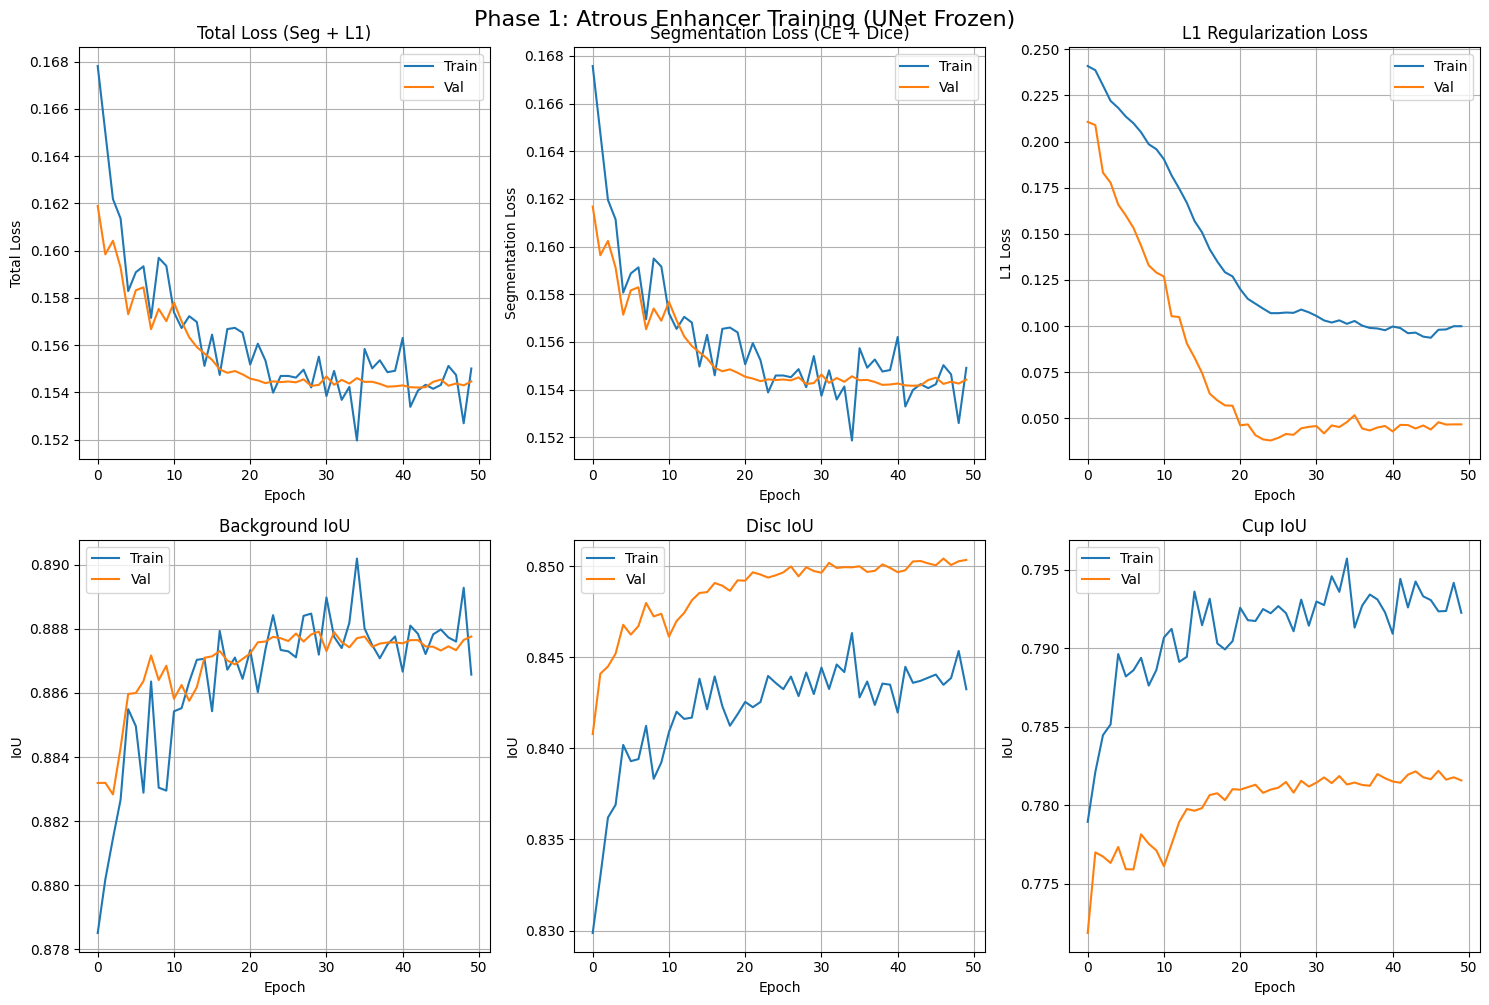

In [4]:
# Create results directory
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

# Plot Phase 1 history
fig1 = plot_training_history(
    history_phase1,
    save_path=str(results_dir / 'atrous_enhancer_phase1_history.png')
)
plt.suptitle('Phase 1: Atrous Enhancer Training (UNet Frozen)', fontsize=16, y=1.00)
plt.show()

Training history saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_phase2_history.png


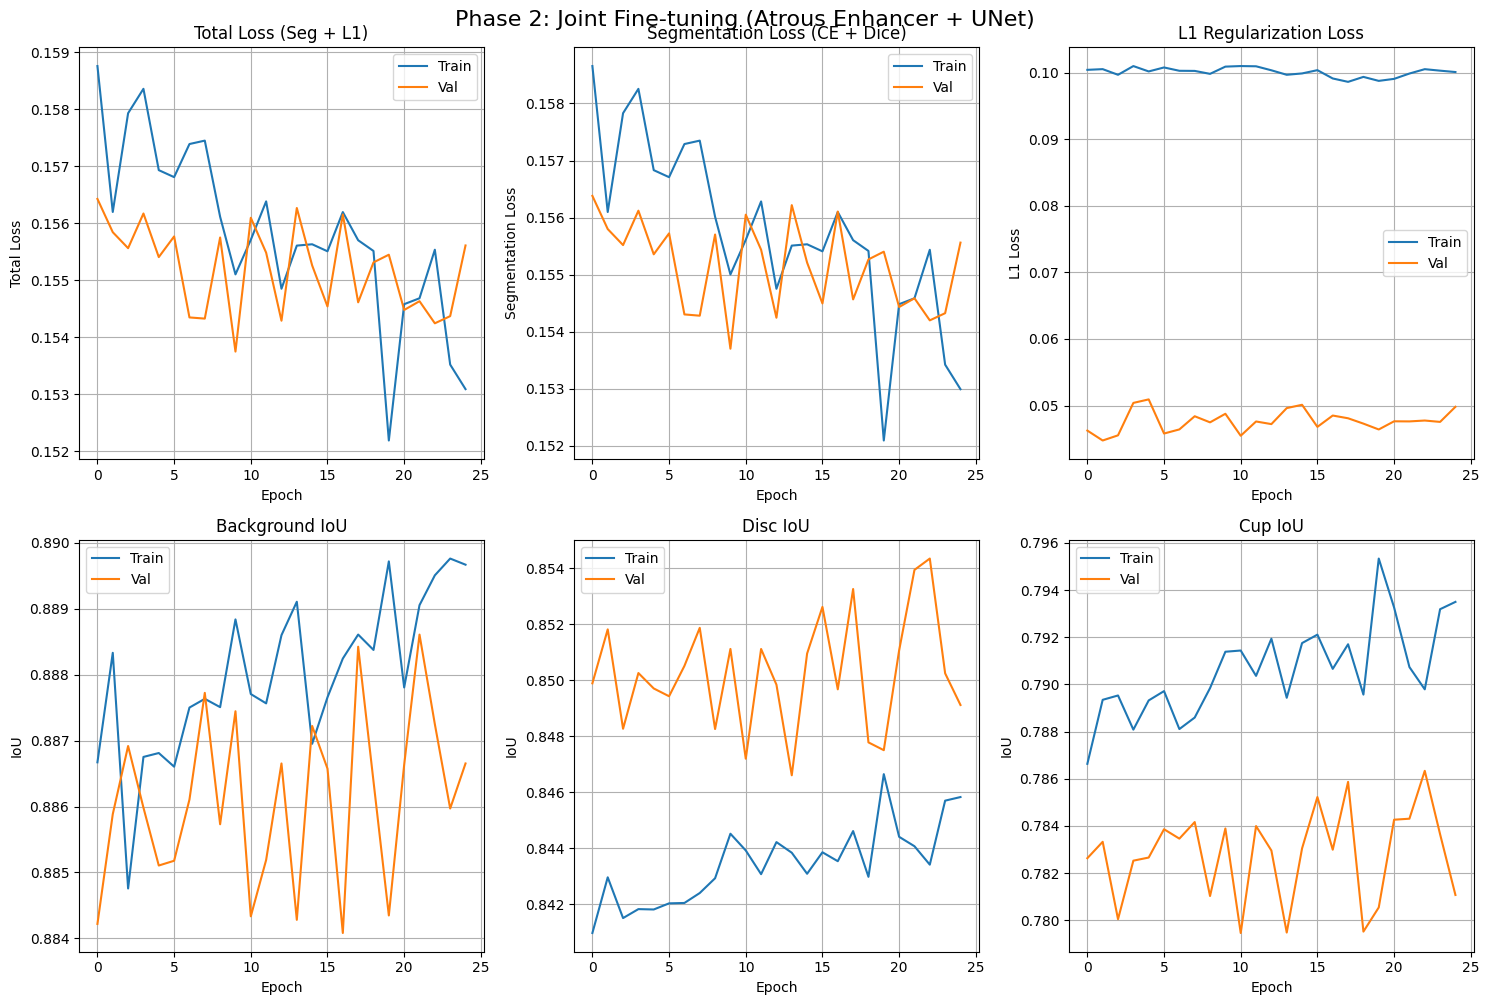

In [5]:
# Plot Phase 2 history
fig2 = plot_training_history(
    history_phase2,
    save_path=str(results_dir / 'atrous_enhancer_phase2_history.png')
)
plt.suptitle('Phase 2: Joint Fine-tuning (Atrous Enhancer + UNet)', fontsize=16, y=1.00)
plt.show()

In [6]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS - Atrous Enhancer + UNet")
print("=" * 80)

print("\n=== PHASE 1 (Atrous Enhancer Only) ===")
print(f"Total Epochs: {len(history_phase1['train_loss'])}")
print("\nFinal Validation Metrics:")
print(f"  Loss:        {history_phase1['val_loss'][-1]:.4f}")
print(f"  Seg Loss:    {history_phase1['val_seg_loss'][-1]:.4f}")
print(f"  L1 Loss:     {history_phase1['val_l1_loss'][-1]:.4f}")
print(f"  IoU (Cup):   {history_phase1['val_iou_cup'][-1]:.4f}")

print("\n=== PHASE 2 (Joint Fine-tuning) ===")
print(f"Total Epochs: {len(history_phase2['train_loss'])}")
print("\nFinal Validation Metrics:")
print(f"  Loss:        {history_phase2['val_loss'][-1]:.4f}")
print(f"  Seg Loss:    {history_phase2['val_seg_loss'][-1]:.4f}")
print(f"  L1 Loss:     {history_phase2['val_l1_loss'][-1]:.4f}")
print(f"  IoU (Cup):   {history_phase2['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss (Phase 2):")
best_epoch = history_phase2['val_loss'].index(min(history_phase2['val_loss'])) + 1
best_val_loss = min(history_phase2['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)



FINAL TRAINING RESULTS - Atrous Enhancer + UNet

=== PHASE 1 (Atrous Enhancer Only) ===
Total Epochs: 50

Final Validation Metrics:
  Loss:        0.1545
  Seg Loss:    0.1544
  L1 Loss:     0.0467
  IoU (Cup):   0.7816

=== PHASE 2 (Joint Fine-tuning) ===
Total Epochs: 25

Final Validation Metrics:
  Loss:        0.1556
  Seg Loss:    0.1556
  L1 Loss:     0.0498
  IoU (Cup):   0.7811

Best Validation Loss (Phase 2):
  Epoch: 10
  Loss:  0.1537



## 5. Print Final Metrics


## 6. Save Training History


In [7]:
# Save histories as JSON
history_path1 = results_dir / 'atrous_enhancer_phase1_history.json'
with open(history_path1, 'w') as f:
    json.dump(history_phase1, f, indent=2)
print(f"Phase 1 history saved to: {history_path1}")

history_path2 = results_dir / 'atrous_enhancer_phase2_history.json'
with open(history_path2, 'w') as f:
    json.dump(history_phase2, f, indent=2)
print(f"Phase 2 history saved to: {history_path2}")

Phase 1 history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_phase1_history.json
Phase 2 history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_phase2_history.json
